In [18]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


### Carregar os dados

In [69]:
df_transactions = pd.read_csv("transacoes_fraude.csv")

In [70]:
df_transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13000 entries, 0 to 12999
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Cliente                     13000 non-null  object 
 1   Tipo de Transacao           13000 non-null  object 
 2   Valor da Transacao          13000 non-null  float64
 3   Valor Anterior a Transacao  13000 non-null  float64
 4   Valor Apos a Transacao      13000 non-null  float64
 5   Horario da Transacao        13000 non-null  object 
 6   Classe                      13000 non-null  int64  
dtypes: float64(3), int64(1), object(3)
memory usage: 711.1+ KB


In [71]:
df_transactions.head(5)

,Cliente,Tipo de Transacao,Valor da Transacao,Valor Anterior a Transacao,Valor Apos a Transacao,Horario da Transacao,Classe
0,cliente1D4F0B,Saque,390.39,5446.75,5056.36,2023-03-14T07:29:28.256579,0
1,clienteCF3D89,Saque,3272.03,12167.89,8895.86,2023-02-12T17:54:09.119410,0
2,cliente0F0D32,PIX,4905.72,8217.63,3311.91,2023-10-03T17:31:42.087599,0
3,clienteFCC0EA,PIX,3073.23,7833.16,4759.93,2024-05-23T17:57:02.055680,0
4,cliente9BA227,PIX,4233.03,6920.82,2687.79,2022-10-07T17:30:36.879557,0


In [72]:
df_transactions.tail(5)

,Cliente,Tipo de Transacao,Valor da Transacao,Valor Anterior a Transacao,Valor Apos a Transacao,Horario da Transacao,Classe
12995,clienteF61967,Saque,1526.11,9680.53,8154.42,2025-04-25T18:48:03.335688,0
12996,cliente51CF5C,PIX,888.23,6677.31,5789.08,2024-10-13T19:31:11.093681,0
12997,cliente0D3251,Saque,4245.13,4926.23,681.10,2023-02-17T22:45:31.584409,0
12998,clienteAFCFB7,Saque,3880.87,7778.95,3898.08,2024-02-10T18:56:08.194584,0
12999,cliente84748D,PIX,3690.41,12992.52,9302.11,2022-11-07T13:29:42.965114,0


### EDA

In [73]:
df_transactions.describe()

,Valor da Transacao,Valor Anterior a Transacao,Valor Apos a Transacao,Classe
count,13000.000000,13000.000000,13000.000000,13000.000000
mean,2511.899952,7547.003386,5035.103435,0.110000
std,1436.446865,3225.212074,2884.967560,0.312902
min,10.000000,95.440000,10.120000,0.000000
25%,1279.412500,5038.805000,2533.727500,0.000000
50%,2525.610000,7538.255000,4997.090000,0.000000
75%,3754.945000,10046.875000,7551.552500,0.000000
max,4999.960000,14897.740000,9999.390000,1.000000


In [74]:
df_transactions.drop(columns=["Cliente"], inplace=True)

In [75]:
# Quais são os tipos de transações
df_transactions["Tipo de Transacao"].unique()

array(['Saque', 'PIX', 'Débito', 'Crédito'], dtype=object)

In [76]:
# Quantidade e percentual dos tipos de transações
count_transactions_type = df_transactions["Tipo de Transacao"].value_counts()
percentual_transactions_type = df_transactions["Tipo de Transacao"].value_counts(normalize=True) * 100

results = pd.DataFrame({
    "quantidade": count_transactions_type,
    "percentual": percentual_transactions_type,
})

print(results)

                   quantidade  percentual
Tipo de Transacao                        
Débito                   3290   25.307692
PIX                      3274   25.184615
Saque                    3244   24.953846
Crédito                  3192   24.553846


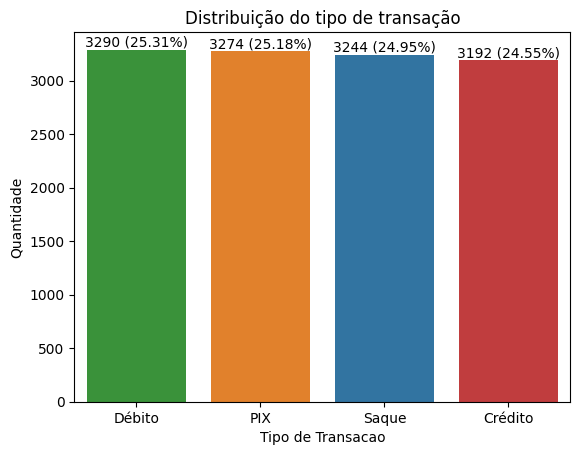

In [77]:
# Gráfico de barras da quantidade dos tipos de transações
total = len(df_transactions)

ax = sns.countplot(
    data=df_transactions,
    x="Tipo de Transacao",
    hue="Tipo de Transacao",
    order=df_transactions["Tipo de Transacao"].value_counts().index
)

for container in ax.containers:
    ax.bar_label(container, labels=[f"{int(v)} ({round((v / total) * 100, 2)}%)" for v in container.datavalues])

plt.title("Distribuição do tipo de transação")
plt.ylabel('Quantidade')
plt.show()


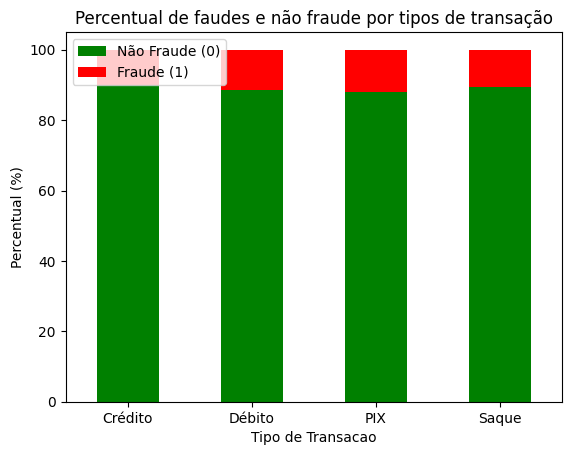

In [78]:
# Gráfico de barras dos percentuais de fraudes e não fraude por tipos de transação
fraud_percentual = df_transactions.groupby("Tipo de Transacao")["Classe"].value_counts(normalize=True).unstack().fillna(0) * 100

fraud_percentual.plot(kind="bar", stacked=True, color=["green", "red"])

plt.title("Percentual de faudes e não fraude por tipos de transação")
plt.ylabel('Percentual (%)')
plt.legend(labels=['Não Fraude (0)', 'Fraude (1)'], loc='upper left')
plt.xticks(rotation=0)
plt.show()

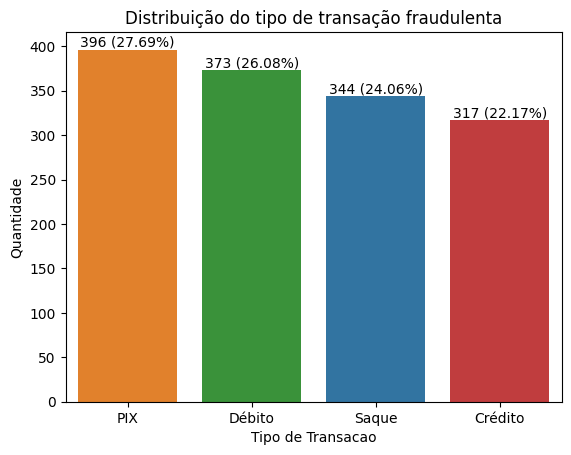

In [79]:
# Gráfico de barras da quantidade de fraudes por tipos de transação
df_filter = df_transactions[df_transactions["Classe"] == 1]

total = len(df_filter)

ax = sns.countplot(
    data=df_filter,
    x="Tipo de Transacao",
    hue="Tipo de Transacao",
    order=df_filter["Tipo de Transacao"].value_counts().index
)

for container in ax.containers:
    ax.bar_label(container, labels=[f"{int(v)} ({round((v / total) * 100, 2)}%)" for v in container.datavalues])

plt.title("Distribuição do tipo de transação fraudulenta")
plt.ylabel('Quantidade')
plt.show()

In [80]:
# Transformação da variável Horario da Transacao
df_transactions["Horario"] = pd.to_datetime(df_transactions['Horario da Transacao']).dt.hour
df_transactions.head(5)

,Tipo de Transacao,Valor da Transacao,Valor Anterior a Transacao,Valor Apos a Transacao,Horario da Transacao,Classe,Horario
0,Saque,390.39,5446.75,5056.36,2023-03-14T07:29:28.256579,0,7
1,Saque,3272.03,12167.89,8895.86,2023-02-12T17:54:09.119410,0,17
2,PIX,4905.72,8217.63,3311.91,2023-10-03T17:31:42.087599,0,17
3,PIX,3073.23,7833.16,4759.93,2024-05-23T17:57:02.055680,0,17
4,PIX,4233.03,6920.82,2687.79,2022-10-07T17:30:36.879557,0,17


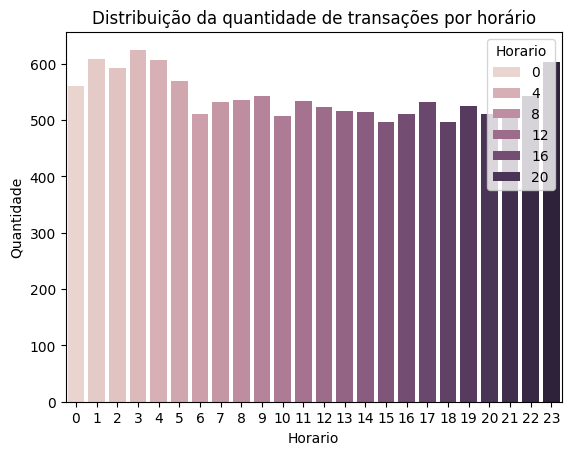

In [96]:
# Gráfico de barras da quantidade de transações por horário
sns.countplot(
    data=df_transactions,
    x="Horario",
    hue="Horario",
)

plt.title("Distribuição da quantidade de transações por horário")
plt.ylabel('Quantidade')
plt.show()

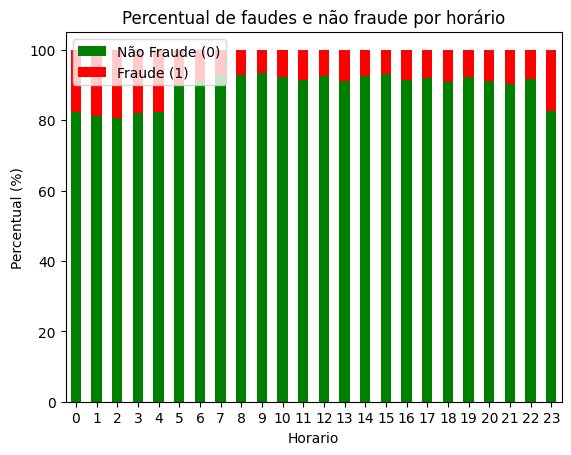

In [94]:
# Gráfico de barras dos percentuais de fraudes e não fraude por horário
fraud_hourly_percentual = df_transactions.groupby("Horario")["Classe"].value_counts(normalize=True).unstack().fillna(0) * 100

fraud_hourly_percentual.plot(kind="bar", stacked=True, color=["green", "red"])

plt.title("Percentual de faudes e não fraude por horário")
plt.ylabel('Percentual (%)')
plt.legend(labels=['Não Fraude (0)', 'Fraude (1)'], loc='upper left')
plt.xticks(rotation=0)
plt.show()

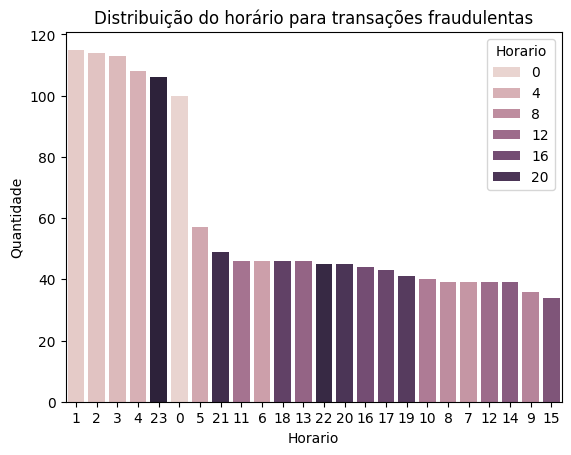

In [81]:
df_filter = df_transactions[df_transactions["Classe"] == 1]

total = len(df_filter)

sns.countplot(
    data=df_filter,
    x="Horario",
    hue="Horario",
    order=df_filter["Horario"].value_counts().index
)


plt.title("Distribuição do horário para transações fraudulentas")
plt.ylabel('Quantidade')
plt.show()

In [ ]:
# Valor da Transacao
# Valor Anterior a Transacao
# Valor Apos a Transacao

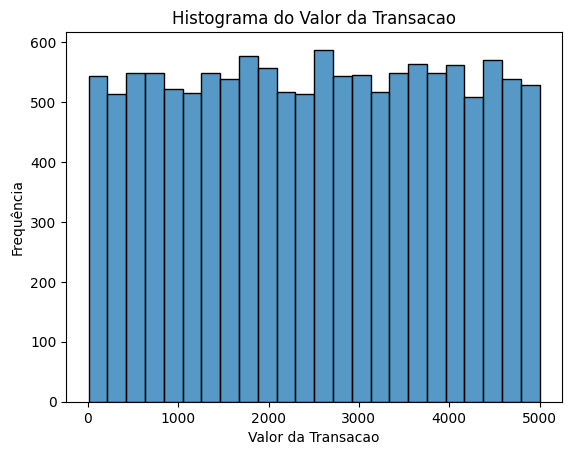

In [86]:
# Histograma da variável Valor da Transacao
sns.histplot(data=df_transactions, x="Valor da Transacao", kde=False)

plt.title("Histograma do Valor da Transacao")
plt.xlabel("Valor da Transacao")
plt.ylabel("Frequência")
plt.show()

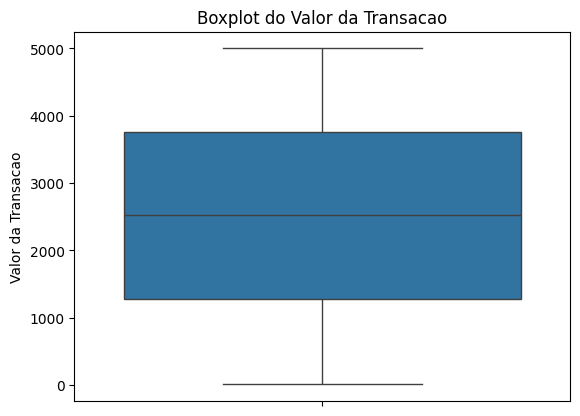

In [87]:
# Boxplot da variável Valor da Transacao
sns.boxplot(data=df_transactions, y="Valor da Transacao")

plt.title("Boxplot do Valor da Transacao")
plt.ylabel("Valor da Transacao")
plt.show()

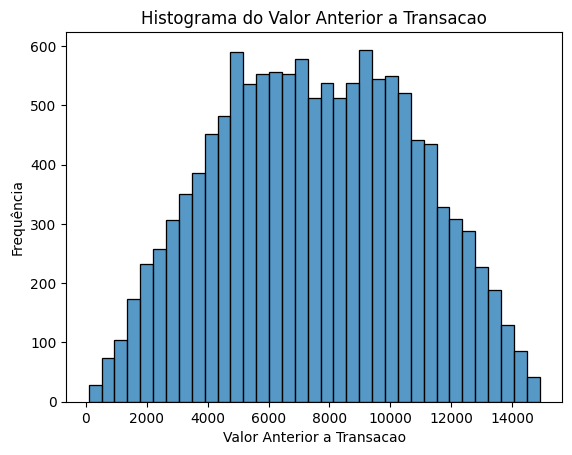

In [88]:
# Histograma da variável Valor Anterior a Transacao
sns.histplot(data=df_transactions, x="Valor Anterior a Transacao", kde=False)

plt.title("Histograma do Valor Anterior a Transacao")
plt.xlabel("Valor Anterior a Transacao")
plt.ylabel("Frequência")
plt.show()

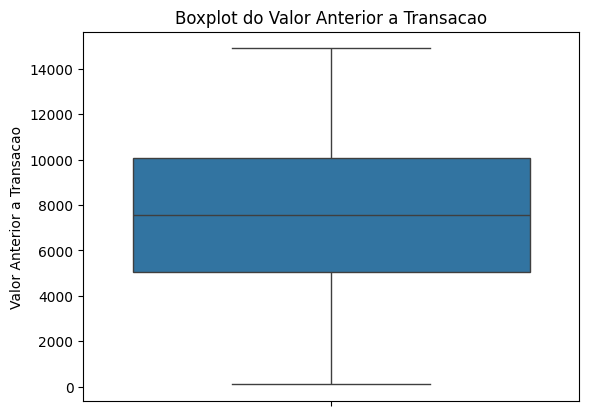

In [89]:
# Boxplot da variável Valor Anterior a Transacao
sns.boxplot(data=df_transactions, y="Valor Anterior a Transacao")

plt.title("Boxplot do Valor Anterior a Transacao")
plt.ylabel("Valor Anterior a Transacao")
plt.show()

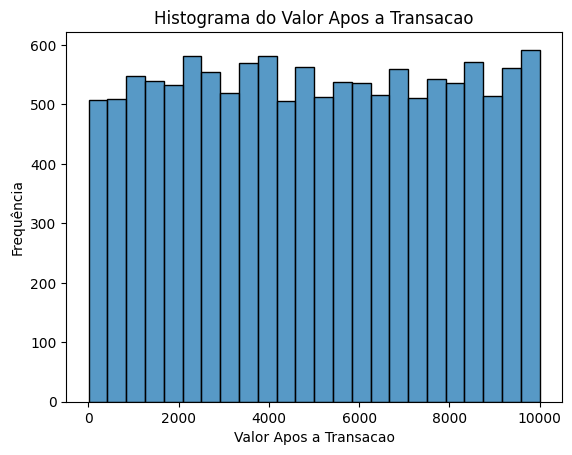

In [90]:
# Histograma da variável Valor Apos a Transacao
sns.histplot(data=df_transactions, x="Valor Apos a Transacao", kde=False)

plt.title("Histograma do Valor Apos a Transacao")
plt.xlabel("Valor Apos a Transacao")
plt.ylabel("Frequência")
plt.show()

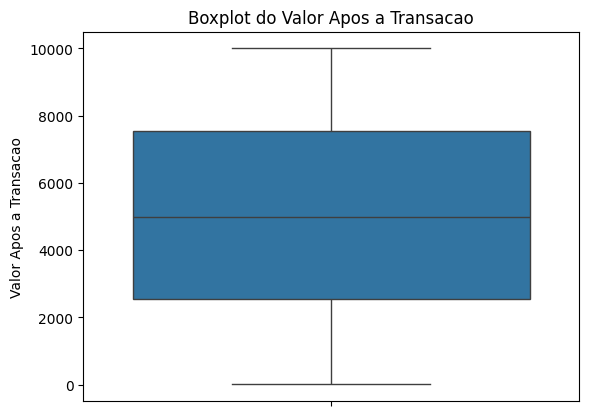

In [91]:
# Boxplot da variável Valor Apos a Transacao
sns.boxplot(data=df_transactions, y="Valor Apos a Transacao")

plt.title("Boxplot do Valor Apos a Transacao")
plt.ylabel("Valor Apos a Transacao")
plt.show()

In [ ]:
# One Hot Encode na variável Tipo de Transacao
df_dummies = pd.get_dummies(df_transactions, columns=["Tipo de Transacao"], prefix="Tipo")
df_dummies.drop(columns=["Horario da Transacao"], inplace=True)
df_dummies.head(5)

,Valor da Transacao,Valor Anterior a Transacao,Valor Apos a Transacao,Classe,Horario,Tipo_Crédito,Tipo_Débito,Tipo_PIX,Tipo_Saque
0,390.39,5446.75,5056.36,0,7,False,False,False,True
1,3272.03,12167.89,8895.86,0,17,False,False,False,True
2,4905.72,8217.63,3311.91,0,17,False,False,True,False
3,3073.23,7833.16,4759.93,0,17,False,False,True,False
4,4233.03,6920.82,2687.79,0,17,False,False,True,False


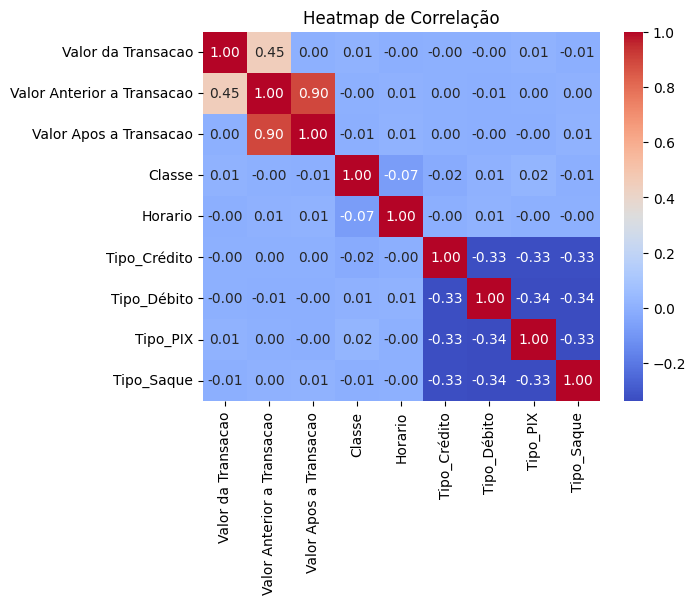

In [102]:
# Heatmap e matriz de correlação
corr = df_dummies.corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Heatmap de Correlação")
plt.show()

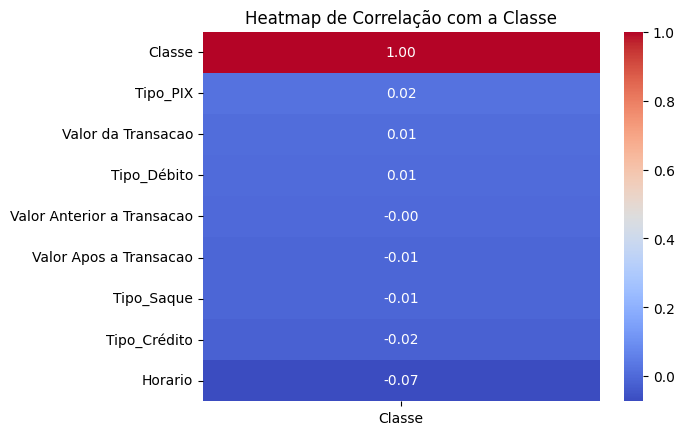

In [103]:
# Heatmap e matriz de correlação em relação a Classe
corr = df_dummies.corr()
corr_target = corr[["Classe"]].sort_values(by="Classe", ascending=False)

sns.heatmap(corr_target, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Heatmap de Correlação com a Classe")
plt.show()

### Modelo Árvore de Decisão

In [108]:
df_model = pd.get_dummies(df_transactions, columns=['Tipo de Transacao'], prefix='Tipo')
df_model.drop(columns=["Horario da Transacao"], inplace=True)

X = df_model.drop(columns=["Classe"])
y = df_model["Classe"]

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=51)

In [112]:
param_grid = {
    "criterion": ["gini", "entropy", "log_loss"],  # só para classificação
    "splitter": ["best", "random"],
    "max_depth": [None, 5, 10, 20, 50],  # controla profundidade da árvore
    "min_samples_split": [2, 5, 10, 20],  # mínimo de amostras para dividir um nó
    "min_samples_leaf": [1, 2, 5, 10],  # mínimo de amostras em uma folha
    "max_features": [None, "sqrt", "log2"],  # nº máx de features consideradas
    "class_weight": [None, "balanced"]  # só para classificação
}

In [113]:
model = DecisionTreeClassifier(random_state=51)

In [114]:
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    verbose=1,
    n_jobs=1
)

In [115]:
grid_search.fit(X_train, y_train)
print("Hiperparâmetros otimizados: \n", grid_search.best_params_)

Fitting 5 folds for each of 2880 candidates, totalling 14400 fits
Hiperparâmetros otimizados: 
 {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 20, 'splitter': 'best'}


In [116]:
optimized_model = grid_search.best_estimator_
y_pred = optimized_model.predict(X_test)

report = classification_report(y_test, y_pred)
print("\nRelatório de Classificação: \n", report)

matrix = confusion_matrix(y_test, y_pred)
print("\nMatriz de Confusão: \n", matrix)

score = accuracy_score(y_test, y_pred)
print("\nAcurácia: \n", score)


Relatório de Classificação: 
               precision    recall  f1-score   support

           0       0.91      0.77      0.83      3468
           1       0.18      0.42      0.26       432

    accuracy                           0.73      3900
   macro avg       0.55      0.59      0.55      3900
weighted avg       0.83      0.73      0.77      3900


Matriz de Confusão: 
 [[2662  806]
 [ 250  182]]

Acurácia: 
 0.7292307692307692


Text(0.5, 1.0, 'Matriz de Confusão')

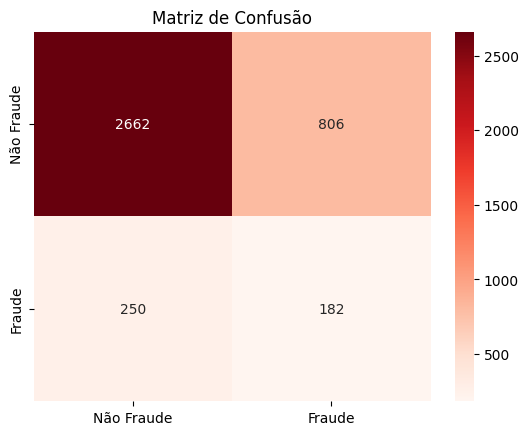

In [121]:
sns.heatmap(matrix, annot=True, fmt="d", cmap="Reds", xticklabels=["Não Fraude", "Fraude"], yticklabels=["Não Fraude", "Fraude"])
plt.title('Matriz de Confusão')

Análise:

- somente 18% das transações classificadas como fraude eram de fato fraudes.
- 91% das transações classificadas como não fraude eram de fato não fraudes.
- 806 falsos positivos (transações não fraudulentas classificadas como fraudes)
- 73% das transações foram classificadas corretamente
- 42% das fraudes foram identificadas pelo modelo
- 26% de f1-score refletinfo o equilíbrio entre recall e precisão

Matriz de confusão:

- Verdadeiros Positivos (fraudes corretamente identificadas) = 182
- Verdadeiros Negativos (não fraudes corretamente identificadas) = 2662
- Falsos Positivos (fraudes classificadas incorretamente) = 806
- Falsos Negativos (não fraudes classificadas incorretamente) = 250

O modelo apresentou baixo desempenho, pois classificou uma quantidade significativa de transações legítimas como fraude e, ao mesmo tempo, deixou de identificar uma parcela relevante de transações fraudulentas, classificando-as incorretamente como legítimas.